# Notebook 03: Iterative Strain Energy Minimization

Determines energetically favorable spatial arrangements of defect inclusions
in an elastic medium by minimizing total elastic strain energy.

**Method:** Starting from a random non-overlapping configuration, each inclusion
is sequentially evaluated over a 3×3 neighborhood of candidate displacements.
The configuration minimizing total strain energy is accepted at each step.
No lattice constraints or chemical interactions are imposed — ordering emerges
purely from elastic cooperativity.

**System:** FeTi + V_O inclusions in STO.  
**Eigenstrain:** εxx = εyy = 0.006373, εxy = 7.44×10⁻⁴

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random
import sys
sys.path.append("../src")
from elasticity_utils import build_greens_function, generate_inclusion_mask, compute_strain_and_energy

plt.rcParams["font.family"] = "Helvetica"

# --- Parameters ---
GRID_SIZE = 128
INCLUSION_RADIUS = 4
NUM_INCLUSIONS = 64
MAX_ITERS = 50
MU, NU = 1.0, 0.25
EIGENSTRAIN = (0.006373, 0.006373, 7.435702e-04)  # FeTi + V_O

Gxx, Gxy, Gyy = build_greens_function(GRID_SIZE, MU, NU)

In [6]:
def initialize_positions(num_inclusions, grid_size, inclusion_radius, seed=42):
    """Generate random non-overlapping inclusion center positions."""
    random.seed(seed)
    positions = []
    min_dist = 2 * inclusion_radius + 1
    max_attempts = 10000

    while len(positions) < num_inclusions:
        for _ in range(max_attempts):
            r = random.randint(inclusion_radius, grid_size - inclusion_radius - 1)
            c = random.randint(inclusion_radius, grid_size - inclusion_radius - 1)
            if all(abs(r - pr) + abs(c - pc) >= min_dist for pr, pc in positions):
                positions.append((r, c))
                break
        else:
            raise RuntimeError("Could not place all inclusions without overlap.")
    return positions

positions = initialize_positions(NUM_INCLUSIONS, GRID_SIZE, INCLUSION_RADIUS)
print(f"Initialized {len(positions)} inclusions.")

Initialized 64 inclusions.


In [7]:
def minimize_strain_energy(positions, grid_size, inclusion_radius, eigenstrain,
                            Gxx, Gxy, Gyy, mu, nu, max_iters=400):
    """
    Iterative local search to minimize total elastic strain energy.
    At each iteration, each inclusion is moved to the neighbor position
    (3x3 grid) that minimizes total system energy.

    Returns optimized positions, energy history, and mean displacement history.
    """
    positions = [list(p) for p in positions]
    energy_history = []
    displacement_history = []

    for iteration in range(max_iters):
        total_displacement = 0

        for idx in range(len(positions)):
            original = positions[idx].copy()
            best_energy = None
            best_pos = original.copy()

            for dr in [-1, 0, 1]:
                for dc in [-1, 0, 1]:
                    nr, nc = original[0] + dr, original[1] + dc
                    if not (inclusion_radius <= nr < grid_size - inclusion_radius and
                            inclusion_radius <= nc < grid_size - inclusion_radius):
                        continue
                    trial = [p.copy() for p in positions]
                    trial[idx] = [nr, nc]
                    exx, eyy, exy = generate_inclusion_mask(
                        trial, grid_size, inclusion_radius, eigenstrain
                    )
                    _, _, _, energy, _ = compute_strain_and_energy(
                        exx, eyy, exy, Gxx, Gxy, Gyy, mu, nu
                    )
                    if best_energy is None or energy < best_energy:
                        best_energy = energy
                        best_pos = [nr, nc]

            total_displacement += np.sqrt(
                (best_pos[0] - original[0])**2 + (best_pos[1] - original[1])**2
            )
            positions[idx] = best_pos

        energy_history.append(best_energy)
        displacement_history.append(total_displacement / len(positions))

    return positions, energy_history, displacement_history


positions, energy_history, displacement_history = minimize_strain_energy(
    positions, GRID_SIZE, INCLUSION_RADIUS, EIGENSTRAIN,
    Gxx, Gxy, Gyy, MU, NU, MAX_ITERS
)
print("Minimization complete.")

Minimization complete.


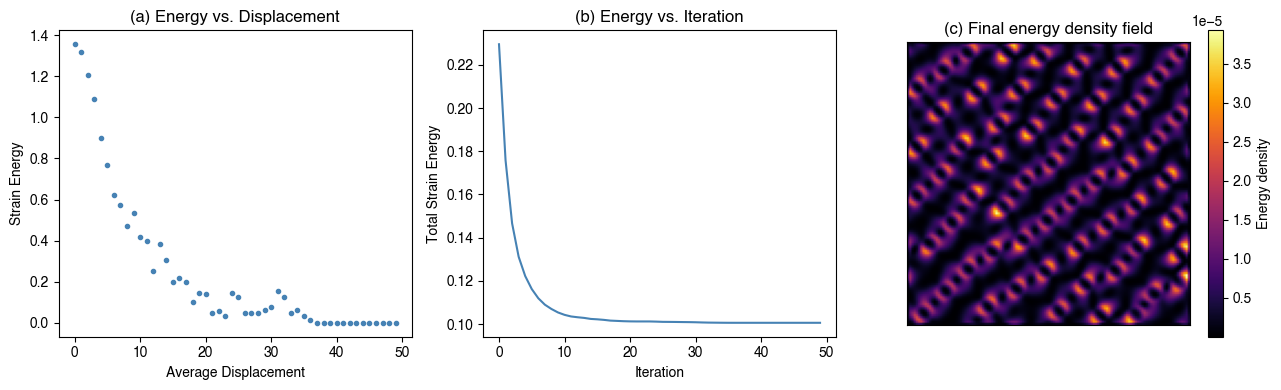

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))

ax1.plot(displacement_history, 'o', markersize=3, color='steelblue')
ax1.set_xlabel("Average Displacement")
ax1.set_ylabel("Strain Energy")
ax1.set_title("(a) Energy vs. Displacement")

ax2.plot(energy_history, color='steelblue', linewidth=1.5)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Total Strain Energy")
ax2.set_title("(b) Energy vs. Iteration")

exx_f, eyy_f, exy_f = generate_inclusion_mask(
    positions, GRID_SIZE, INCLUSION_RADIUS, EIGENSTRAIN
)
_, _, energy_density, _, _ = compute_strain_and_energy(
    exx_f, eyy_f, exy_f, Gxx, Gxy, Gyy, MU, NU
)
im = ax3.imshow(energy_density, cmap="inferno", origin="lower")
plt.colorbar(im, ax=ax3, label="Energy density")
ax3.set_title("(c) Final energy density field")
ax3.set_xticks([]); ax3.set_yticks([])

plt.tight_layout()
plt.savefig("../figures/energy_minimization_convergence.png", dpi=150, bbox_inches="tight")
plt.show()